## Simulating traffic around a lock
In this notebook, we simulate a lock on a network which two opposingly directed vessels have to pass. We add a pre-coded complex lock object on the graph: only one vessel can be levelled at a time. The second vessel waits until the first vessel has passed the lock. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
import numpy as np

# import of modules important for locking
from opentnsim.lock import lock_new as lock_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.graph.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 2. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.MultiDiGraph()

# add nodes
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))

# add edges
graph.add_edge('0','1',geometry=transform(wgs84eqd_to_wgs84rad,LineString([Point(-5000,0),Point(5000,0)])),length_m=10000, weight=1)
graph.add_edge('1','0',geometry=transform(wgs84eqd_to_wgs84rad,LineString([Point(5000,0),Point(-5000,0)])),length_m=10000, weight=1);


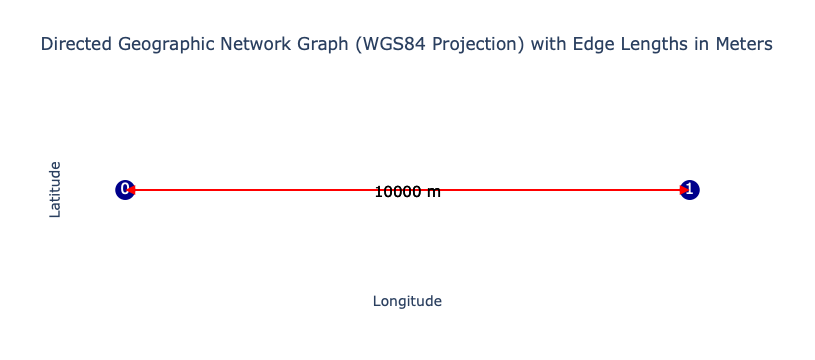

In [4]:
opentnsim.graph.plot_graph(graph)

#### 3. Run simulation

In [5]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [6]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
env.graph = graph

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=graph)

# create lock
lock = lock_module.IsLockComplex(
    env=env,
    name='Lock',
    node_open='0',
    node_A = '0',
    node_B = '1',
    distance_lock_doors_A_to_waiting_area_A = 4800,
    distance_lock_doors_B_to_waiting_area_B = 4800,
    distance_from_start_node_to_lock_doors_A = 4800,
    distance_from_end_node_to_lock_doors_B = 4800,
    lock_length = 400,
    lock_width = 50,
    lock_depth = 15,
    levelling_time = 300,
    sailing_distance_to_crossing_point = 1800,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.5,
    sailing_in_time_gap_through_doors = 300,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 120,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    detector_nodes = ['0','1'],
    predictive=True
)

# create vessels from dict 
vessel_speed_outside_of_lock = 4. 

data_vessel_in = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": vessel_speed_outside_of_lock,                   # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 10,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  

data_vessel_out = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['1']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "1", "0"),      # required by Routeable
    "v": vessel_speed_outside_of_lock,                   # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 10,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  

In [7]:
n_max = 4

# Part III, Ch3, Eq. 3.2 (NB: de helft van de looptime wordt hier effectief geimplementeerd door de sailing to lock te berekenen)
t_sailing_to_lock = lock.sailing_distance_to_crossing_point/vessel_speed_outside_of_lock
T_entering = t_sailing_to_lock + (n_max-1)*lock.sailing_in_time_gap_through_doors + 50/2

# Part III, Ch3, Eq. 3.3
T_operation = lock.doors_closing_time + lock.levelling_time + lock.doors_opening_time

# Part III, Ch3, Eq. 3.4 (NB: de helft van de looptime wordt hier effectief geimplementeerd door de sailing out of lock te berekenen)
t_sailing_out_of_lock = lock.sailing_distance_to_crossing_point/vessel_speed_outside_of_lock
T_exiting = t_sailing_out_of_lock + (n_max-1)*lock.sailing_out_time_gap_through_doors + 350/2

# Part III, Ch3, Eq. 3.1
T_locking = T_entering + T_operation + T_exiting
T_c = 2 * T_locking

C_s = 2*n_max / (T_c/3600)

print(f"The capacity of the lock is {np.round(C_s,1)} vessels per hour")

The capacity of the lock is 4.4 vessels per hour


In [8]:
IC = 1
T_arrival = T_locking*(1/IC)

In [9]:
predicted_arrival_moments = pd.date_range(simulation_start+pd.Timedelta(seconds=3000/4),simulation_start+pd.Timedelta(days=1),freq=pd.Timedelta(seconds=T_arrival))

In [10]:
vessels = []
vessel_index = 1
for index,start_time in enumerate(predicted_arrival_moments):
    start_time -= pd.Timedelta(seconds=3000/4)

    new_arrival_time = start_time
    if not index%2:
        for index_vessel_in_operation in np.arange(1,5):     
            data_vessel_in["arrival_time"] = new_arrival_time
            vessel = Vessel(**data_vessel_in)
            vessel.name = f'Vessel {vessel_index}'
            env.process(mission(env, vessel))
            new_arrival_time += pd.Timedelta(minutes=5)
            vessels.append(vessel)
            vessel_index += 1

    else:
        for index_vessel_in_operation in np.arange(1,5):     
            data_vessel_out["arrival_time"] = new_arrival_time
            vessel = Vessel(**data_vessel_out)
            vessel.name = f'Vessel {vessel_index}'
            env.process(mission(env, vessel))
            new_arrival_time += pd.Timedelta(minutes=5)
            vessels.append(vessel)
            vessel_index += 1
            
    if vessel_index >= 16:
        break
        
env.run()

{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'1': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'1': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'1': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'1': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'0': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'1': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'1': <opentnsim.lock.lock_new.IsLockComplex object at 0x175fc2610>}
{'1': <opentnsim.lock.lock_new.IsL

In [11]:
lock.operation_pre_planning

,bound,vessels,capacity_L,capacity_B,time_potential_lock_door_opening_stop,time_operation_start,time_entry_start,time_entry_stop,time_door_closing_start,time_door_closing_stop,...,time_door_opening_stop,time_departure_start,time_departure_stop,time_operation_stop,time_potential_lock_door_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,0,"[<__main__.Vessel object at 0x175fcfd50>, <__m...",0,-30,2025-01-01 00:10:00,2025-01-01 00:12:30,2025-01-01 00:20:00,2025-01-01 00:35:33.333333333,2025-01-01 00:35:33.333333333,2025-01-01 00:40:33.333333333,...,2025-01-01 00:50:33.333333333,2025-01-01 00:50:33.333333333,2025-01-01 01:00:36.313895097,2025-01-01 01:08:06.313895097,2025-01-01 01:02:36.313895097,NaN,NaN,0 days 00:11:40,0 days 00:23:20,ready
1,1,"[<__main__.Vessel object at 0x169254890>, <__m...",0,-30,2025-01-01 01:05:36.313895097,2025-01-01 01:08:06.313895097,2025-01-01 01:15:36.313895097,2025-01-01 01:31:09.647228430,2025-01-01 01:31:09.647228430,2025-01-01 01:36:09.647228430,...,2025-01-01 01:46:09.647228430,2025-01-01 01:46:09.647228430,2025-01-01 01:56:12.627790194,2025-01-01 02:03:42.627790194,2025-01-01 01:58:12.627790194,NaN,NaN,0 days 00:12:56.313895097,0 days 00:24:36.313895097,ready
2,0,"[<__main__.Vessel object at 0x1776513d0>, <__m...",0,-30,2025-01-01 02:01:12.627790194,2025-01-01 02:03:42.627790194,2025-01-01 02:11:12.627790194,2025-01-01 02:26:45.961123527,2025-01-01 02:26:45.961123527,2025-01-01 02:31:45.961123527,...,2025-01-01 02:41:45.961123527,2025-01-01 02:41:45.961123527,2025-01-01 02:51:48.941685291,2025-01-01 02:59:18.941685291,2025-01-01 02:53:48.941685291,NaN,NaN,0 days 00:14:12.627790194,0 days 00:25:52.627790194,ready
3,1,"[<__main__.Vessel object at 0x177655f50>, <__m...",0,-30,2025-01-01 02:56:48.941685291,2025-01-01 02:59:18.941685291,2025-01-01 03:06:48.941685291,2025-01-01 03:22:22.275018624,2025-01-01 03:22:22.275018624,2025-01-01 03:27:22.275018624,...,2025-01-01 03:37:22.275018624,2025-01-01 03:37:22.275018624,2025-01-01 03:47:25.255580388,2025-01-01 03:54:55.255580388,2025-01-01 03:49:25.255580388,NaN,NaN,0 days 00:15:28.941685291,0 days 00:27:08.941685291,ready


#### 4. Inspect output

In [12]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock.logbook)

print("'{}' logbook data:".format(lock.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock doors closing start,2025-01-01 00:35:33.333333,{},0
1,Lock doors closing stop,2025-01-01 00:40:33.333333,{},0
2,Lock chamber converting start,2025-01-01 00:40:33.333333,{},0
3,Lock chamber converting stop,2025-01-01 00:45:33.333333,{},1
4,Lock doors opening start,2025-01-01 00:45:33.333333,{},1
5,Lock doors opening stop,2025-01-01 00:50:33.333333,{},1
6,Lock doors closing start,2025-01-01 01:31:10.000000,{},1
7,Lock doors closing stop,2025-01-01 01:36:10.000000,{},1
8,Lock chamber converting start,2025-01-01 01:36:10.000000,{},1
9,Lock chamber converting stop,2025-01-01 01:41:10.000000,{},0


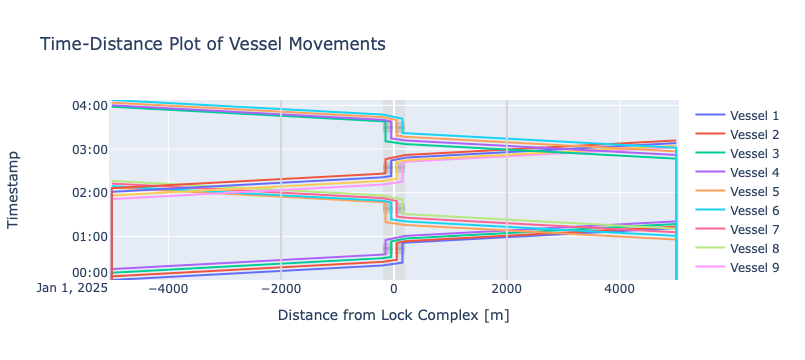

In [13]:
# We can plot the time-distance diagram
lock.create_time_distance_plot_plotly(
    vessels = vessels, 
    xlimmin = -5050, 
    xlimmax = 5050
)

In [14]:
delays = []
for vessel in vessels:
    vessel_df = pd.DataFrame(vessel.logbook)
    waiting_stop = vessel_df[vessel_df.Message == "Waiting stop"]
    if not waiting_stop.empty:
        delay = (waiting_stop.Timestamp-vessel.metadata["arrival_time"]).iloc[0]
    else:
        delay = pd.Timedelta(seconds=0)
    delays.append(delay)

In [15]:
print(f"The average vessel delay is {np.round(np.average(delays).total_seconds()/60,1)} minutes")

The average vessel delay is 1.9 minutes


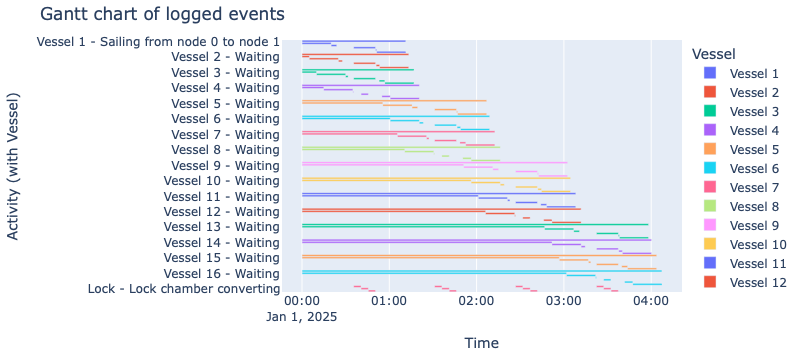

In [16]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([*vessels, lock])
generate_vessel_gantt_chart(df_eventtable)

#### Thinking of a way to analyse Intensity
'get_vessels_during_leveling':
- Identify locking cycles (by looking at the lock logbook)
- From the vessel list identify which vessels were in the lock during that locking cycle

'calculate_cycle_looptimes':
- Using the info derived from 'get_vessels_during_leveling' calculate looptimes

'calculate_detailed_cycle_time':
- using the info from 'get_vessels_during_leveling' and 'calculate_cycle_looptimes' calculate detailed cycle times

In [17]:
leveling_cycles = opentnsim.lock.logutils.get_vessels_during_leveling(lock, vessels)
looptimes_df = opentnsim.lock.logutils.calculate_cycle_looptimes(leveling_cycles, vessels)
Tc_df = opentnsim.lock.logutils.calculate_detailed_cycle_time(lock, vessels, leveling_cycles)

display(pd.DataFrame(leveling_cycles))
display(looptimes_df)
display(Tc_df)

,leveling_start,leveling_stop,vessels_present
0,2025-01-01 00:40:33.333333,2025-01-01 00:45:33.333333,"[Vessel 1, Vessel 2, Vessel 3, Vessel 4]"
1,2025-01-01 01:36:10.000000,2025-01-01 01:41:10.000000,"[Vessel 5, Vessel 6, Vessel 7, Vessel 8]"
2,2025-01-01 02:31:46.000000,2025-01-01 02:36:46.000000,"[Vessel 9, Vessel 10, Vessel 11, Vessel 12]"
3,2025-01-01 03:27:22.275018,2025-01-01 03:32:22.275018,"[Vessel 13, Vessel 14, Vessel 15, Vessel 16]"


,cycle,looptime_seconds
0,1,0.000000
1,2,900.000000
2,3,899.647229
3,4,899.961124


,t_l_up,sum_t_i_up,T_close_up,T_waterlevel_up,T_open_up,sum_t_u_up,t_l_down,sum_t_i_down,T_close_down,T_waterlevel_down,T_open_down,sum_t_u_down,Tc_seconds,up_vessels,down_vessels,I_s
0,0.000000,933.333333,300.0,300.0,300.0,602.980562,900.000000,933.333333,300.0,300.0,300.0,602.980561,5772.627789,"[Vessel 1, Vessel 2, Vessel 3, Vessel 4]","[Vessel 5, Vessel 6, Vessel 7, Vessel 8]",4.989062
1,899.647229,933.333333,300.0,300.0,300.0,602.980561,899.961124,933.333333,300.0,300.0,300.0,602.980562,6672.236142,"[Vessel 9, Vessel 10, Vessel 11, Vessel 12]","[Vessel 13, Vessel 14, Vessel 15, Vessel 16]",4.316394


In [18]:
for index, row in Tc_df.iterrows():
    print('Locking cycle {} has an intensity of {:.2f} vessels per hour'.format(index+1, row['I_s']))

Locking cycle 1 has an intensity of 4.99 vessels per hour
Locking cycle 2 has an intensity of 4.32 vessels per hour
